### Overview

This code explores the spectral distances among graphs of a given family.

In [26]:
import sys
import os
from os.path import dirname, abspath
sys.path.insert(0, os.path.join(abspath(os.getcwd()), 'modules'))

from graphs import get_graph, compute_matrix_of_pairwise_spectral_distances
import numpy as np
import networkx as nx

matrix_types = ['adjacency', 'laplacian', 'signless_laplacian', 'normalized_laplacian', 'distance_normalized_laplacian']
n = 100
n_graphs_per_param_val = 10

In [34]:
np.concatenate([np.linspace(0.1, 0.99, 8), np.array([1])])

array([0.1       , 0.22714286, 0.35428571, 0.48142857, 0.60857143,
       0.73571429, 0.86285714, 0.99      , 1.        ])

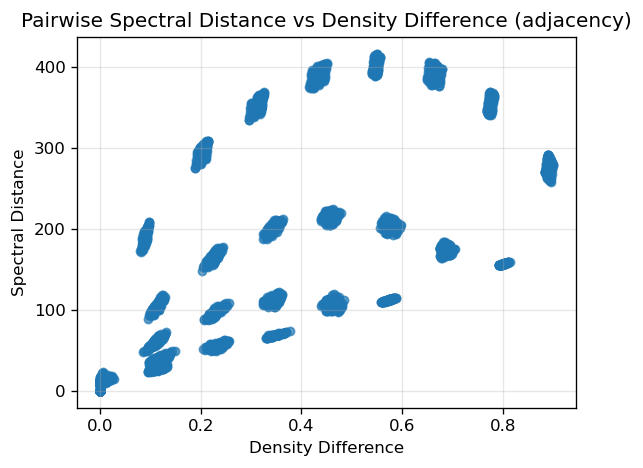

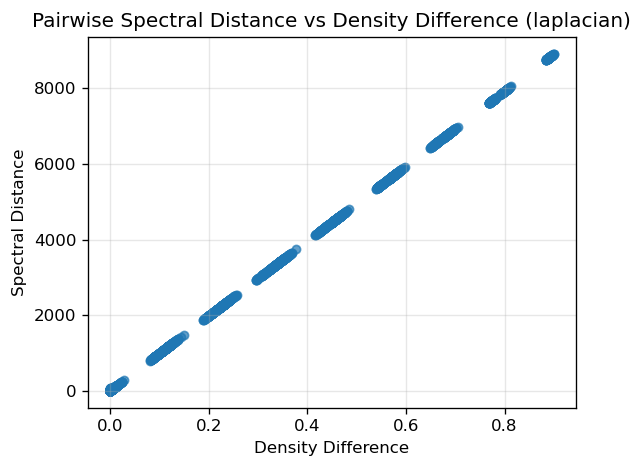

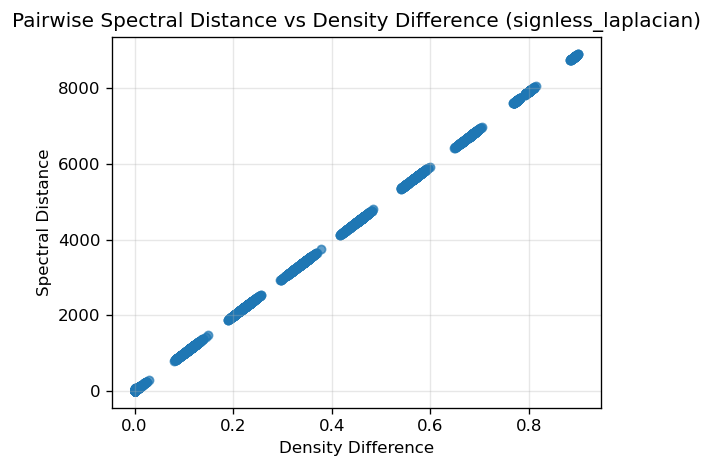

c:\Users\usama\OneDrive\Desktop\distinguish-control-graphs\modules\graphs.py:97: RuntimeWarning: divide by zero encountered in divide
  D_recip = np.diag(1.0 / np.sqrt(deg))
c:\Users\usama\OneDrive\Documents\misc\micromamba\envs\usual\Lib\site-packages\numpy\_core\numeric.py:2363: RuntimeWarning: One of rtol or atol is not valid, atol: nan, rtol: 0.0
  res = all(isclose(a, b, rtol=rtol, atol=atol, equal_nan=equal_nan))


RuntimeError: Matrix is not symmetric. Norm of differnce: nan. Max val: nan

In [35]:
# p_values = np.linspace(0.3, 0.7, 5)   # the plot for the adjacency matrix is more linear in this range
p_values = np.concatenate([np.linspace(0.1, 0.9, 8), np.array([0.99])])
graphs_ER = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values for _ in range(n_graphs_per_param_val)]
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(graphs_ER, matrix_type=matrix_type, plot_type='scatter')

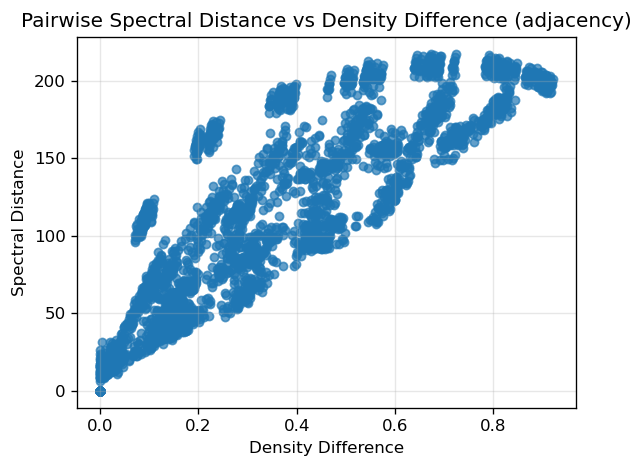

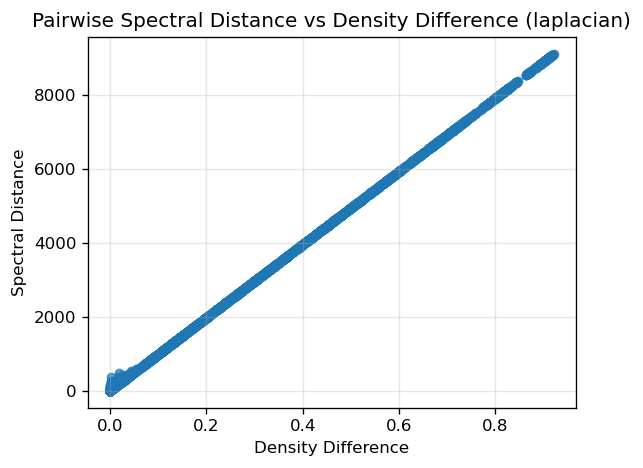

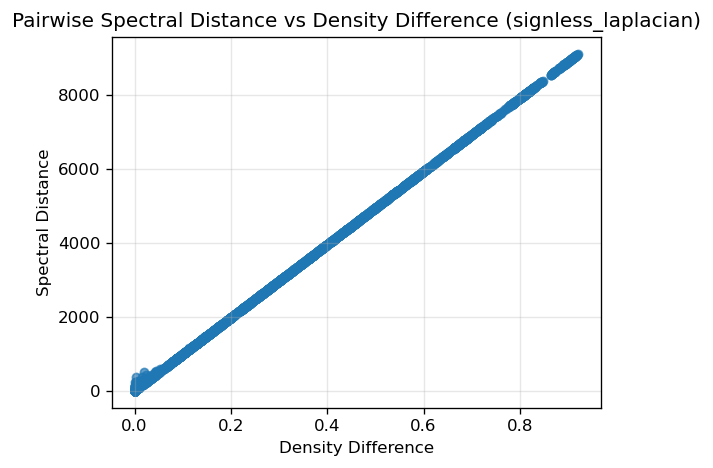

RuntimeError: Matrix is not symmetric. Norm of differnce: nan. Max val: nan

In [28]:
# r_values = np.linspace(0.25, 0.75, 6)     # the plot for adjacency matrix is more linear for this range
r_values = np.linspace(0.1, 0.9, 8)
graphs_RG = [get_graph({'type': 'RG', 'n': n, 'r': r}) for r in r_values for _ in range(n_graphs_per_param_val)]
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(graphs_RG, matrix_type=matrix_type, plot_type='scatter')

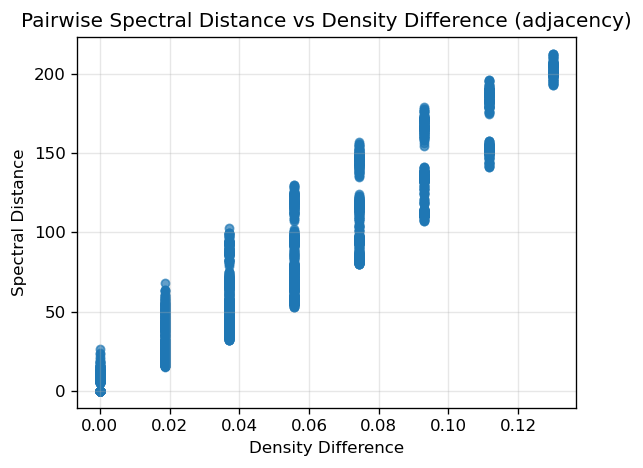

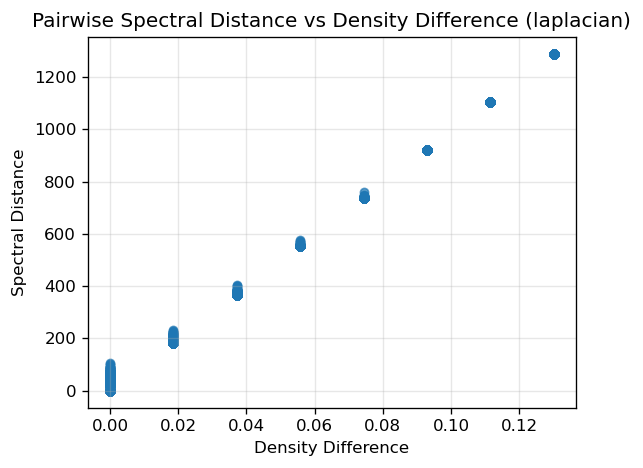

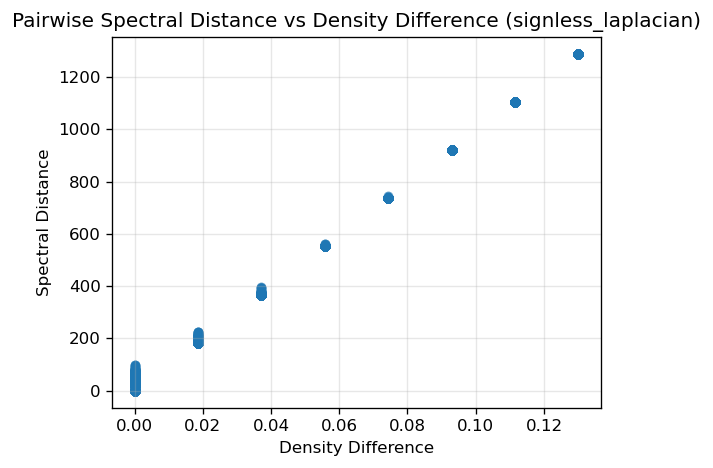

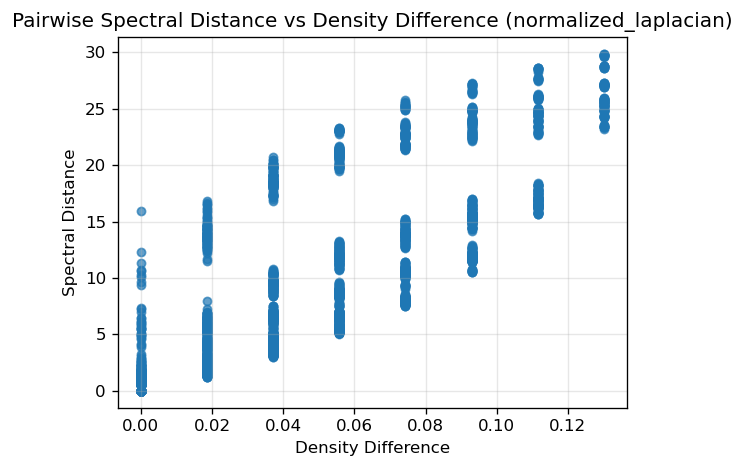

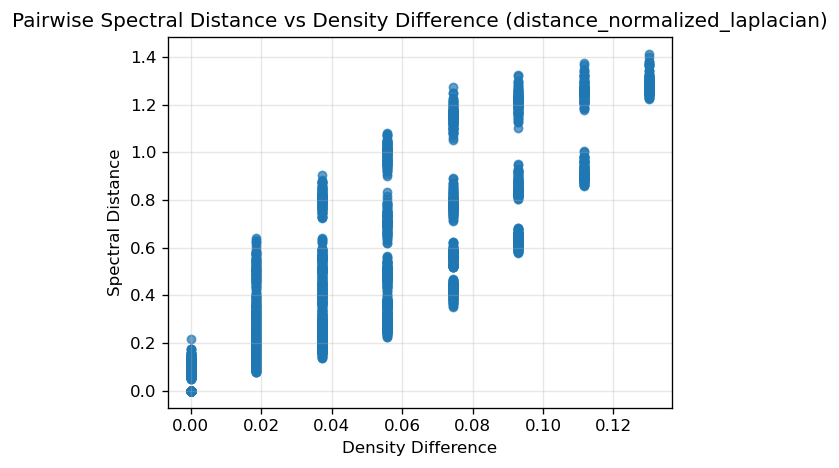

In [29]:
m_values = np.linspace(1, 8, 8)
graphs_BA = [get_graph({'type': 'BA', 'n': n, 'm': m, 'init': {'type': 'complete', 'n': 8}}) for m in m_values for _ in range(n_graphs_per_param_val)]
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(graphs_BA, matrix_type=matrix_type, plot_type='scatter')

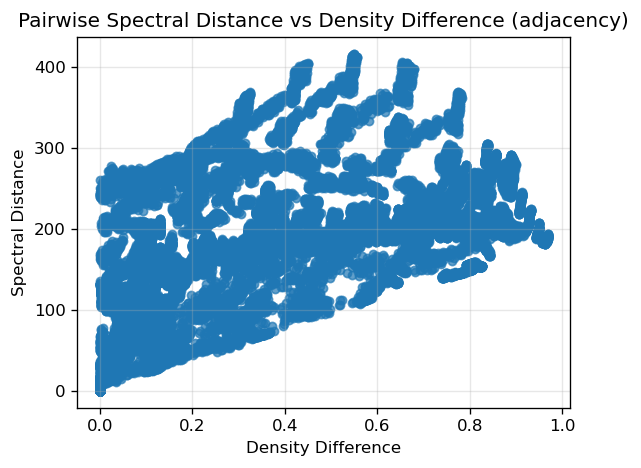

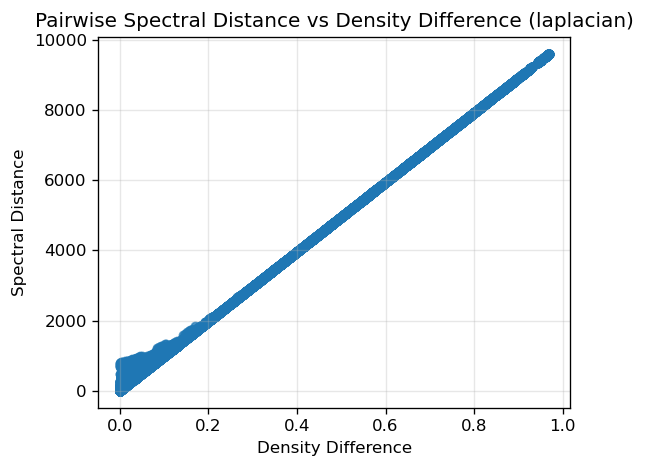

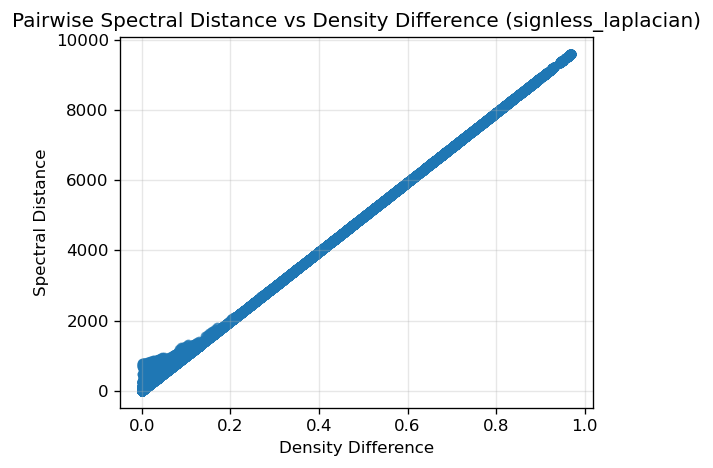

RuntimeError: Matrix is not symmetric. Norm of differnce: nan. Max val: nan

In [36]:
all_graphs = graphs_ER + graphs_RG + graphs_BA
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(all_graphs, matrix_type=matrix_type, plot_type='scatter')

Processing graphs: 100%|██████████| 3/3 [00:01<00:00,  1.70it/s]


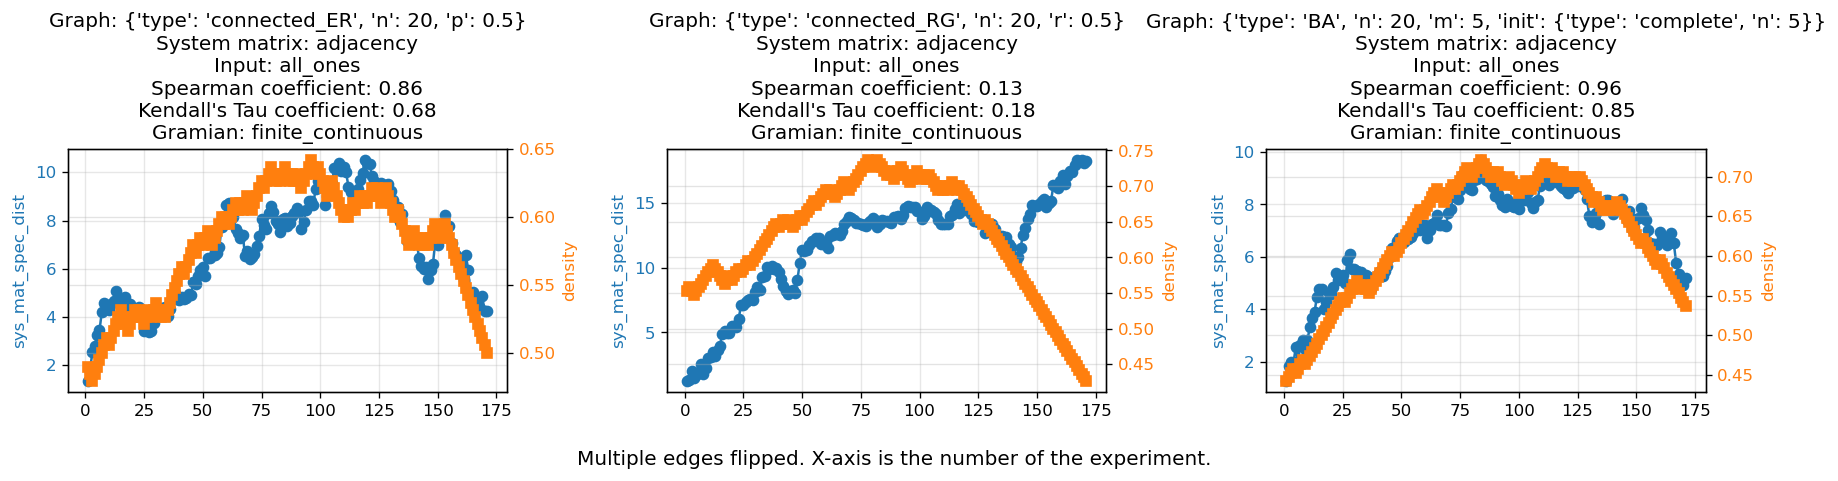

Processing graphs: 100%|██████████| 3/3 [00:01<00:00,  1.61it/s]


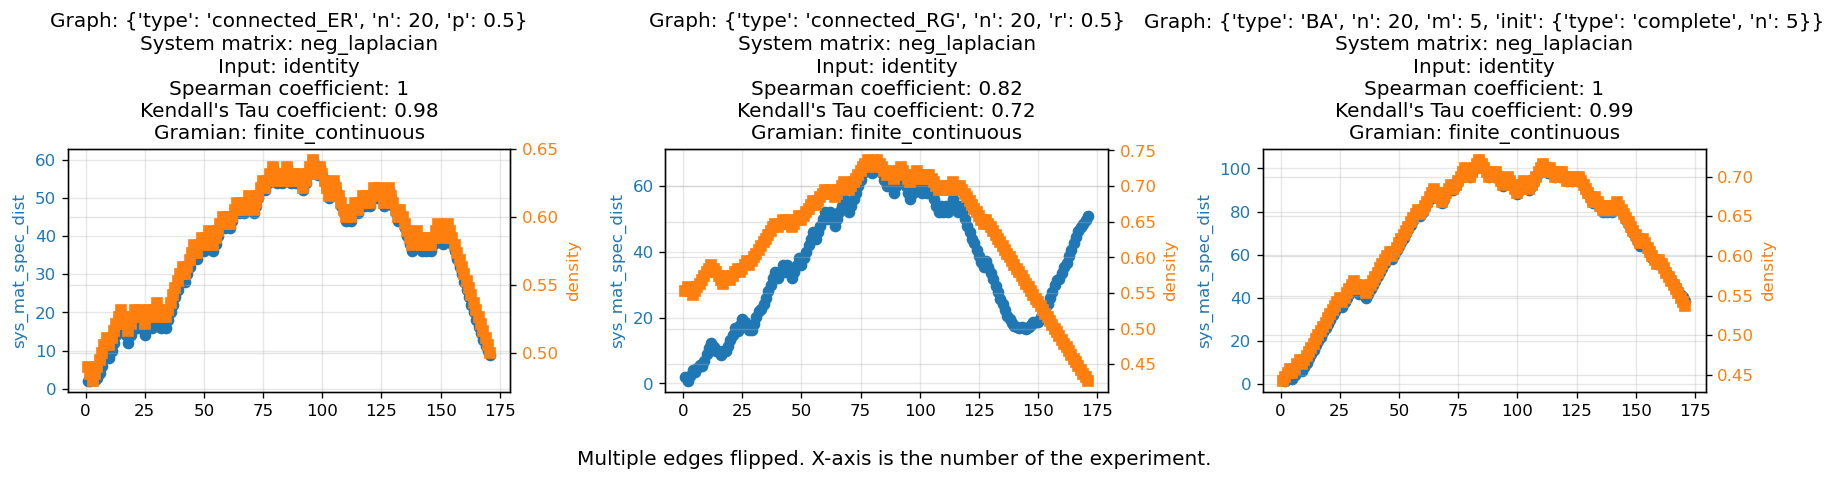

Processing graphs: 100%|██████████| 3/3 [00:01<00:00,  2.02it/s]


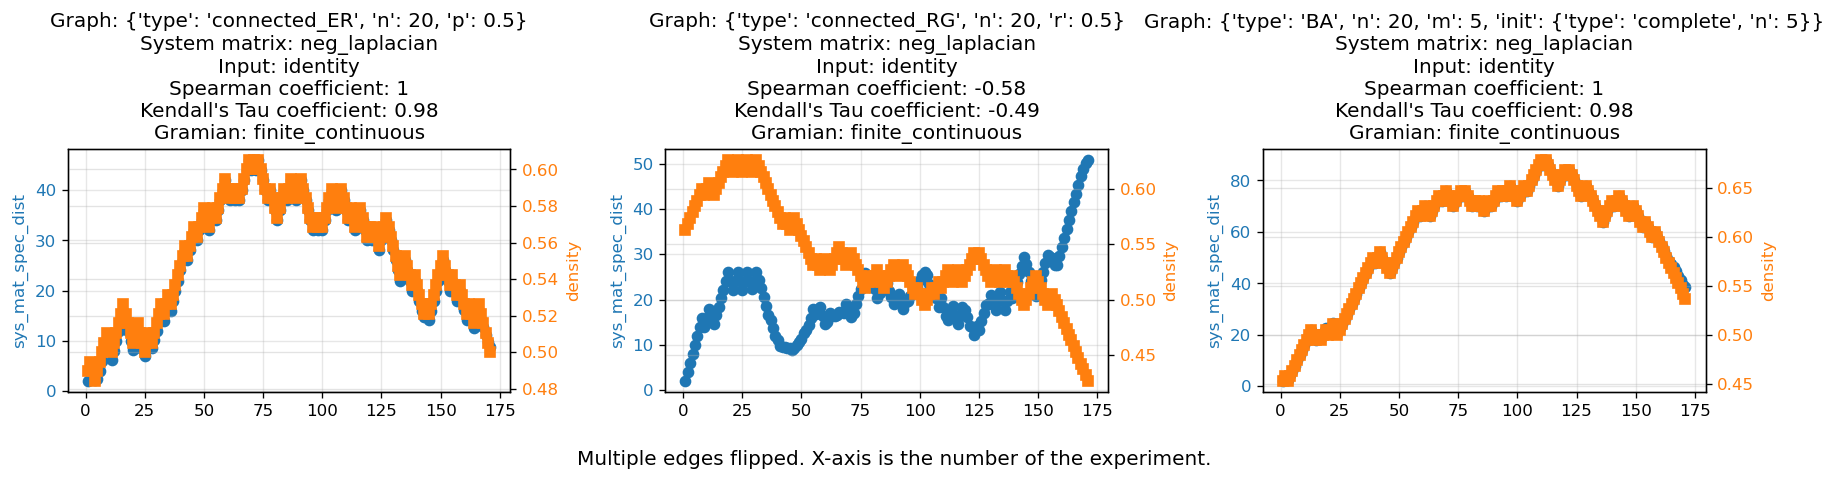

In [ ]:
from modules.single_graph_edge_expt import graph_edge_toggling_expt_using_given_graphs_and_scoring_choice
from modules.graphs import get_graph
import numpy as np
# %config InlineBackend.figure_format = 'svg'

graph_choices = [{'type': 'connected_ER', 'n': 20, 'p': 0.5},
                 {'type': 'connected_RG', 'n': 20, 'r': 0.5},
                 {'type':           'BA', 'n': 20, 'm': 5, 'init': {'type': 'complete', 'n': 5}}]
graphs = [get_graph(graph_choice=choice) for choice in graph_choices]
matrix_choices = ['adjacency', 'neg_laplacian', 'normalized_laplacian', 'neg_normalized_laplacian',
                  'signless_laplacian', 'neg_signless_laplacian', 'distance_normalized_laplacian', 'neg_distance_normalized_laplacian']
# input_choices = ['all_ones', 'identity', 'identity_transf', 'zfs', 'zfs_transf', 'zfs_new']
input_choices = ['all_ones', 'identity', 'zfs', 'zfs_transf', 'zfs_new']

G = graphs[0]
rand_edge_order = {(u, v): np.random.rand() for u in G.nodes() for v in G.nodes() if u != v}



graph_edge_toggling_expt_using_given_graphs_and_scoring_choice(graph_choices, graphs, matrix_choices=['adjacency'], input_choices=['all_ones'],
        edge_score_choices=['ETEC'], t_horizon_setting_for_ETEC='2n', multiple_toggles=True, plot_all_ignoring_low_corr=True,
        plot_this='density')

graph_edge_toggling_expt_using_given_graphs_and_scoring_choice(graph_choices, graphs, matrix_choices=['neg_laplacian'], input_choices=['identity'],
        edge_score_choices=['ETEC'], t_horizon_setting_for_ETEC='2n', multiple_toggles=True, plot_all_ignoring_low_corr=True,
        plot_this='density')

graph_edge_toggling_expt_using_given_graphs_and_scoring_choice(graph_choices, graphs, matrix_choices=['neg_laplacian'], input_choices=['identity'],
        edge_score_choices=['ETEC_sys_mat'], t_horizon_setting_for_ETEC='2n', multiple_toggles=True, plot_all_ignoring_low_corr=True,
        plot_this='density')

Processing graphs: 100%|██████████| 3/3 [00:01<00:00,  1.96it/s]


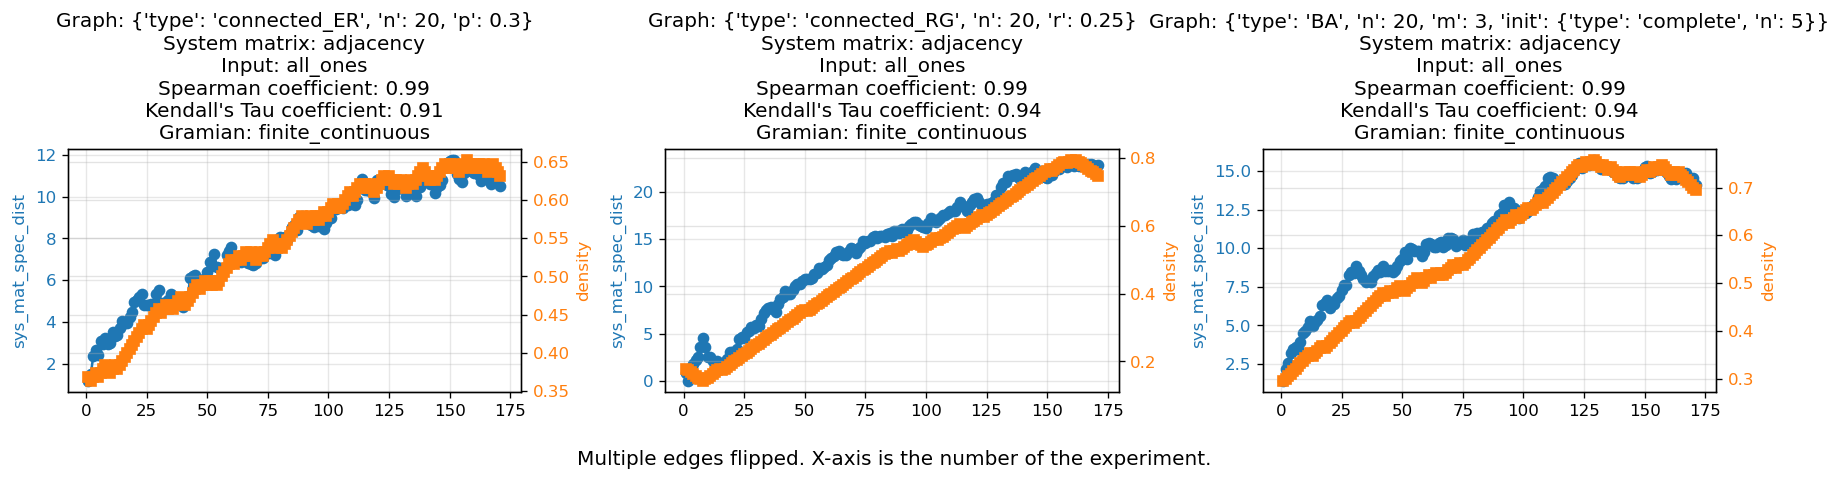

Processing graphs: 100%|██████████| 3/3 [00:01<00:00,  1.86it/s]


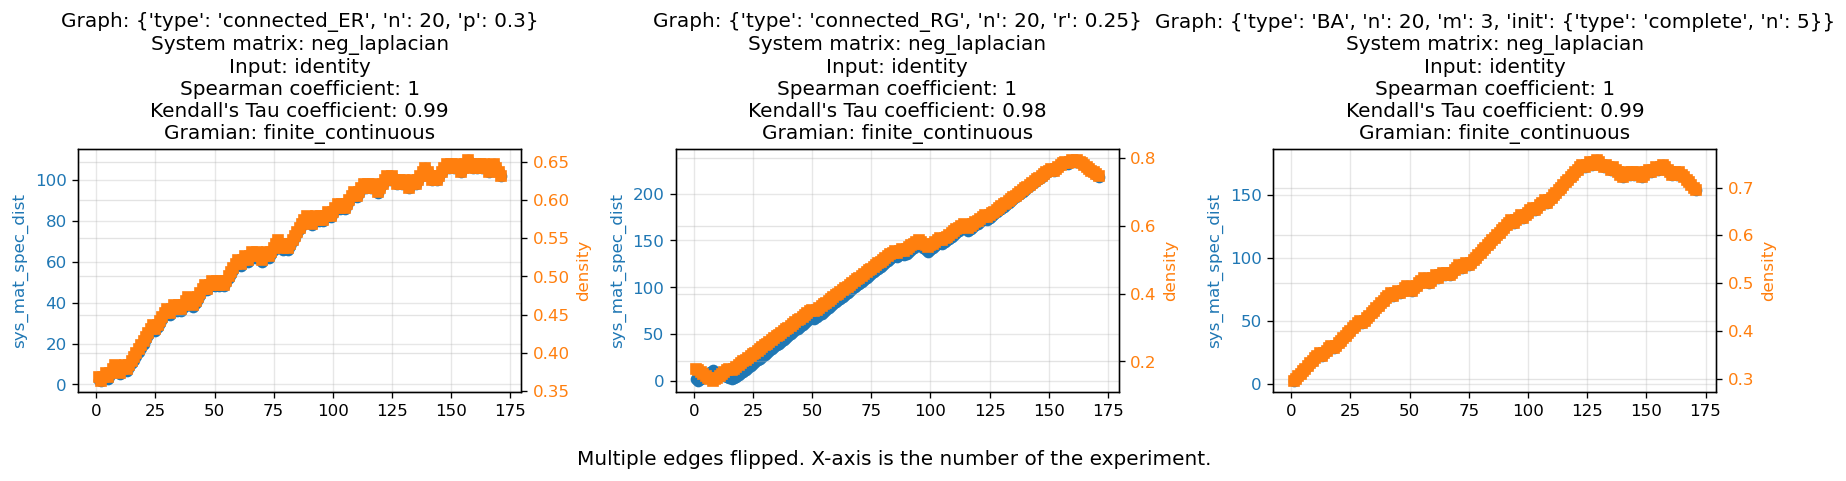

Processing graphs: 100%|██████████| 3/3 [00:01<00:00,  2.32it/s]


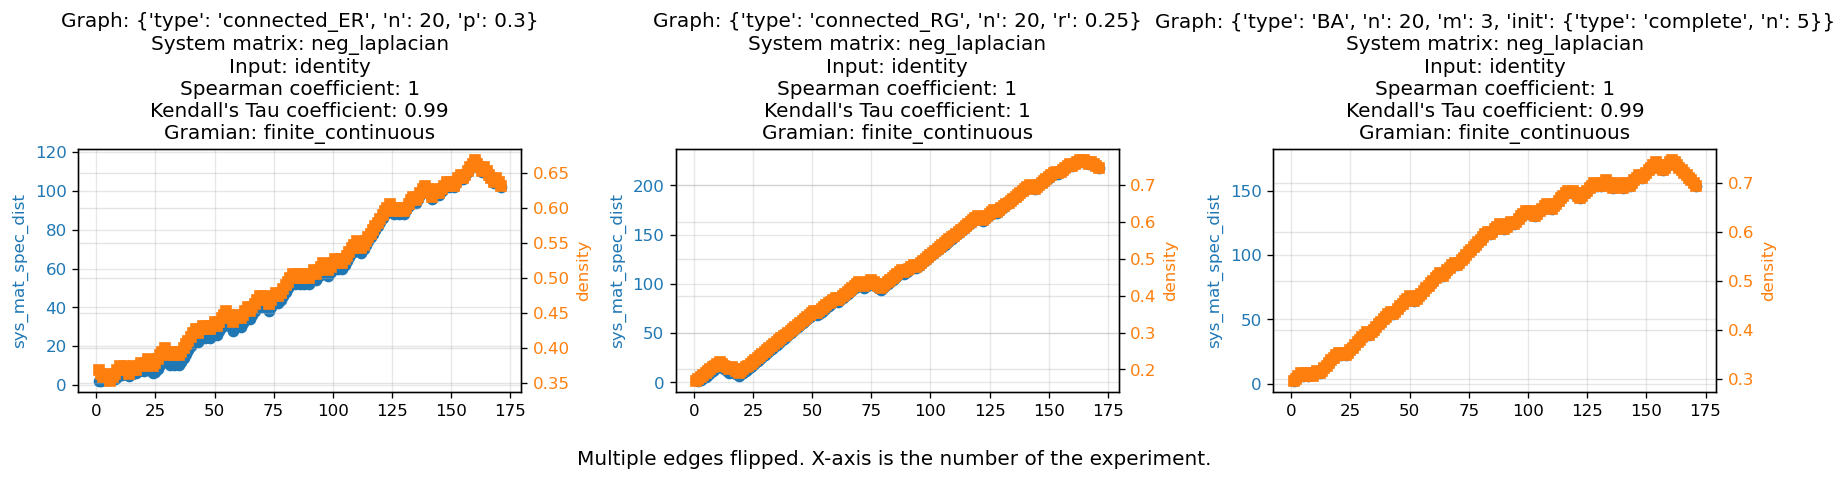

In [ ]:
from modules.single_graph_edge_expt import graph_edge_toggling_expt_using_given_graphs_and_scoring_choice
from modules.graphs import get_graph
import numpy as np
# %config InlineBackend.figure_format = 'svg'

graph_choices = [{'type': 'connected_ER', 'n': 20, 'p': 0.3},
                 {'type': 'connected_RG', 'n': 20, 'r': 0.25},
                 {'type':           'BA', 'n': 20, 'm': 3, 'init': {'type': 'complete', 'n': 5}}]
graphs = [get_graph(graph_choice=choice) for choice in graph_choices]
matrix_choices = ['adjacency', 'neg_laplacian', 'normalized_laplacian', 'neg_normalized_laplacian',
                  'signless_laplacian', 'neg_signless_laplacian', 'distance_normalized_laplacian', 'neg_distance_normalized_laplacian']
# input_choices = ['all_ones', 'identity', 'identity_transf', 'zfs', 'zfs_transf', 'zfs_new']
input_choices = ['all_ones', 'identity', 'zfs', 'zfs_transf', 'zfs_new']

G = graphs[0]
rand_edge_order = {(u, v): np.random.rand() for u in G.nodes() for v in G.nodes() if u != v}



graph_edge_toggling_expt_using_given_graphs_and_scoring_choice(graph_choices, graphs, matrix_choices=['adjacency'], input_choices=['all_ones'],
        edge_score_choices=['ETEC'], multiple_toggles=True, plot_all_ignoring_low_corr=True, plot_this='density')

graph_edge_toggling_expt_using_given_graphs_and_scoring_choice(graph_choices, graphs, matrix_choices=['neg_laplacian'], input_choices=['identity'],
        edge_score_choices=['ETEC'], multiple_toggles=True, plot_all_ignoring_low_corr=True, plot_this='density')

graph_edge_toggling_expt_using_given_graphs_and_scoring_choice(graph_choices, graphs, matrix_choices=['neg_laplacian'], input_choices=['identity'],
        edge_score_choices=['ETEC_sys_mat'], multiple_toggles=True, plot_all_ignoring_low_corr=True, plot_this='density')